# Task 2 Machine Learning Modelling on Smart Manufacturing and IoT Monitoring Dataset

## Objective

The objective of this notebook is to develop, tune and evaluate a machine learning classification pipeline using pycaret, to predict whether a machine is in need of maintenance. The target variable of this task is `maintenance_required`, a binary label where `1` means maintenance is needed at the time of the reading.

The dataset has 100,000 sensor readings taken from 50 machines, and each reading has five continuous sensor channels: temperature, vibration, humidity, pressure and energy consumption. The target is imbalanced, with about 80.3% of readings labeled `0` and 19.7% labeled `1`.

Predictive maintenance has unbalanced cost for errors, a false negative when a model predicts a faulty machine doesnt need maintenance, might lead to downtime and increased repair costs down the line, while a false positive triggers an unnecessary inspection, which is far cheaper than missing a faulty machine. Hence, making accuracy a misleading objectie where a model can still achieve a high accuracy of ~80.3% by simply predicting the majority class. Therefore, the optimization metric being focused on here is F1 score, which is the harmonic mean of precision and recall, which corrects the class imbalance.

## 1. Setup, imports and configuration

Dependencies are managed with poetry and recorded in `pyproject.toml` and `poetry.lock`. The `%pip install` lines below are kept on purpose. The jupyter kernel runs inside the poetry virtual environment, so a package installed from an activated conda shell would not be visible to it. Using the `%pip` magic installs into the interpreter that is actually running the notebook, which avoids a recurring "package installed but not found" problem.

In [14]:
%pip install pycaret
%pip install xgboost
import pandas as pd 
import matplotlib.pyplot as plt
import pycaret
from pycaret.classification import *
from pycaret.classification import ClassificationExperiment
import mlflow
import os
from hydra import compose, initialize
from omegaconf import OmegaConf

with initialize(version_base=None, config_path="../conf"):
    cfg = compose(config_name="config")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Load processed data

The processed file produced by the EDA notebook has the five sensor channels and the target. A few columns from the raw extract were dropped during EDA because they leak the answer to the model:

| Column | Reason for dropping |
|---|---|
| `downtime_risk` | Almost perfectly correlated with `anomaly_flag` (correlation about 0.999998), so it is a near duplicate of a label derived signal |
| `anomaly_flag` | Derived from the machine's known condition instead of being measured on its own |
| `failure_type` | Names the failure that already happened, which is not known beforehand |
| `predicted_remaining_life` | Output of another predictive model, not a raw measurement |
| `machine_status` | Its maintenance state maps one to one onto the target |
| `timestamp`, `machine_id` | Identifiers, not predictors |

Keeping any of these would give a model with great scores that cannot work in deployment, because none of them are known at the point where a prediction has to be made. 

In [15]:
df = pd.read_csv('../data/processed/smart_manufacturing_processed.csv')
df.head()

,temperature,vibration,humidity,pressure,energy_consumption,maintenance_required
0,78.61,28.65,79.96,3.73,2.16,0
1,68.19,57.28,35.94,3.64,0.69,0
2,98.94,50.20,72.06,1.00,2.49,1
3,90.91,37.65,30.34,3.15,4.96,1
4,72.32,40.69,56.71,2.68,0.63,1


## 3. Temporal features & outlier handling

### 3.1 Why temporal context matters

Individual sensor readings don't predict failure. Degradation trends such rising vibration, temperature drift, instability. A single value is static; sequential values show drift. We need to capture how each machine has been behaving over its recent history.

### 3.2 Outliers

Raw sensors have noise and faults. `vibration` goes negative (impossible), and both `temperature` and `vibration` have physical extremes that don't reflect true machine state. Winsorize at 1st/99th percentile instead of dropping rows—keeps temporal continuity and treats sensor noise as noise, not missing data.

### 3.3 Features added

| Feature | Window | Why |
|---------|--------|-----|
| `*_lag1` (all sensors) | — | Previous reading for comparison |
| Rolling mean (temp, vib, energy) | 5 | Recent operating baseline |
| Rolling std (temp, vib, energy) | 5 | Instability signal—erratic sensors often precede failure |
| `temperature_delta`, `vibration_delta` | — | Drift direction and speed |
| `temp_x_vib` | — | Thermal-mechanical stress proxy |

### 3.4 No leakage

All features computed within machine (`groupby('machine_id')`) using only backward-looking windows (`shift()`, rolling from past). Drop first read per machine (no history). Dataset: 100,000 → 99,950 rows, 19 features. Class balance unchanged.

In [16]:
raw = pd.read_csv('../data/raw/smart_manufacturing_data.csv')
raw['timestamp'] = pd.to_datetime(raw['timestamp'])
raw = raw.sort_values(['machine_id', 'timestamp']).reset_index(drop=True)

for col in ['vibration', 'temperature']:
    q = raw[col].quantile([0.01, 0.99])
    raw[col] = raw[col].clip(q.iloc[0], q.iloc[1])

g = raw.groupby('machine_id')
sensors = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']

for s in sensors:
    raw[f'{s}_lag1'] = g[s].shift(1)

for s in ['temperature', 'vibration', 'energy_consumption']:
    raw[f'{s}_roll_mean'] = g[s].transform(lambda x: x.rolling(5, min_periods=1).mean())
    raw[f'{s}_roll_std'] = g[s].transform(lambda x: x.rolling(5, min_periods=1).std().fillna(0))

for s in ['temperature', 'vibration']:
    raw[f'{s}_delta'] = raw[s] - raw[f'{s}_lag1']

raw['temp_x_vib'] = raw['temperature'] * raw['vibration']

df = raw.drop(columns=['timestamp', 'machine_id', 'downtime_risk',
                       'failure_type', 'predicted_remaining_life',
                       'anomaly_flag', 'machine_status']).dropna()
print(f"Featured data: {df.shape[0]} rows x {df.shape[1]} columns (incl. target)")
df.head()


Featured data: 99950 rows x 20 columns (incl. target)


,temperature,vibration,humidity,pressure,energy_consumption,maintenance_required,temperature_lag1,vibration_lag1,humidity_lag1,pressure_lag1,energy_consumption_lag1,temperature_roll_mean,temperature_roll_std,vibration_roll_mean,vibration_roll_std,energy_consumption_roll_mean,energy_consumption_roll_std,temperature_delta,vibration_delta,temp_x_vib
1,70.88,68.67,50.57,1.05,2.36,0,62.59,48.08,60.13,1.62,4.16,66.735,5.861915,58.375000,14.559329,3.260000,1.272792,8.29,20.59,4867.3296
2,62.34,72.68,60.47,2.24,4.95,0,70.88,68.67,50.57,1.05,2.36,65.270,4.860010,63.143333,13.198410,3.823333,1.327416,-8.54,4.01,4530.8712
3,88.03,53.36,50.79,3.08,2.25,0,62.34,72.68,60.47,2.24,4.95,70.960,12.052007,60.697500,11.834713,3.430000,1.339229,25.69,-19.32,4697.2808
4,79.39,49.44,56.99,2.54,2.76,0,88.03,53.36,50.79,3.08,2.25,72.646,11.097348,58.446000,11.418913,3.296000,1.197886,-8.64,-3.92,3925.0416
5,93.62,47.52,58.38,2.63,1.12,1,79.39,49.44,56.99,2.54,2.76,78.852,12.637423,58.334000,11.548021,2.688000,1.403556,14.23,-1.92,4448.8224


## 4. Experiment tracking with MLflow

MLflow logs every run to local storage (`mlruns/`), keeping results reproducible and comparable. Set `tracking_uri` to `''` (local file store) and suppress gitpython warnings with `GIT_PYTHON_REFRESH='quiet'`.

With `log_experiment='mlflow'` in `setup()`, each model from `compare_models()` and `tune_model()` logs automatically: hyperparameters, cross-validated metrics, everything. The `mlruns/` folder grows large and stays local-only, so add it to `.gitignore`.

In [17]:
os.environ["GIT_PYTHON_REFRESH"] = "quiet"
mlflow.set_tracking_uri("")
mlflow.set_experiment(cfg.model.experiment_name)

<Experiment: artifact_location='file:///c:/Users/glenv/OneDrive/Documents/y3s1%20notes/Term%202/IT3385%20-%20Machine%20Learning%20Operations/assignment/javian/notebooks/mlruns/185081072885344560', creation_time=1787229459102, experiment_id='185081072885344560', last_update_time=1787229459102, lifecycle_stage='active', name='smart_manufacturing_experiment', tags={}>

## 5. Setup: preprocessing & cross-validation

`setup()` reads from hydra config.

| Argument | Value | Reason |
|---|---|---|
| `train_size` | 0.8 | 80/20 split; holdout untouched (honest test) |
| `session_id` | 42 | Reproducible randomness |
| `fix_imbalance` | `True` | SMOTE: 80.3/19.7 → balanced |
| `normalize` | `True` | Z-score; essential for knn, svm |
| `transformation` | `True` | Yeo-johnson; handles negative deltas |
| `feature_selection` | `False` | All 19 kept; each has stated purpose |
| `fold` | 10 | 10-fold stratified CV |
| `n_jobs` | 4 | `-1` uses 14 cores; ran OOM on this machine |

SMOTE inflates training only (79,960 → 128,434 rows); test stays 19,990 at original imbalance. 

In [ ]:
exp = ClassificationExperiment()

exp.setup(df, target=cfg.model.target,
          session_id=cfg.model.random_state,
          fix_imbalance=cfg.preprocess.fix_imbalance,
          normalize=cfg.preprocess.normalize,
          transformation=cfg.preprocess.transformation,
          feature_selection=cfg.preprocess.feature_selection,
          fold_strategy=cfg.training.fold_strategy,
          fold=cfg.training.fold,
          train_size=cfg.training.train_size,
          n_jobs=cfg.training.n_jobs,
          log_experiment='mlflow',
          experiment_name=cfg.model.experiment_name)

,Description,Value
0,Session id,42
1,Target,maintenance_required
2,Target type,Binary
3,Original data shape,"(99950, 20)"
4,Transformed data shape,"(148424, 20)"
5,Transformed train set shape,"(128434, 20)"
6,Transformed test set shape,"(19990, 20)"
7,Numeric features,19
8,Preprocess,True
9,Imputation type,simple


## 6. Compare models using k-fold cross-validation

`compare_models()` trains PyCaret's classifier library under the same preprocessing pipeline and ranks by cross-validated performance.

**Metric: F1** (not accuracy). Accuracy gives ~0.803 by guessing majority class every time. F1 (harmonic mean of precision and recall) only scores well if the model finds machines needing maintenance *and* is right when it flags them. Stored in config as `model.sort_metric`.

**Top 3 candidates** (`n_select=3`). The untuned ranking is an estimate; closely ranked models often fall within noise. Carrying three forward lets tuning decide instead of relying on the initial order.

**Exclude GBC**. 10-fold fit + 50-trial optuna search is too slow at this scale. XGBoost and LightGBM cover boosted trees, so one implementation is lost, not the whole approach.

In [ ]:
best = exp.compare_models(sort='F1', n_select=3, exclude=['gbc'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8605,0.7253,0.4741,0.7217,0.5721,0.4930,0.5086,5.5030
rf,Random Forest Classifier,0.8459,0.7262,0.4853,0.6443,0.5535,0.4626,0.4695,23.7750
xgboost,Extreme Gradient Boosting,0.7919,0.7246,0.5283,0.4744,0.4998,0.3689,0.3698,1.7920
ada,Ada Boost Classifier,0.7801,0.7249,0.5394,0.4512,0.4912,0.3524,0.3548,7.9320
qda,Quadratic Discriminant Analysis,0.7577,0.7127,0.5490,0.4140,0.4715,0.3186,0.3242,1.4160
lda,Linear Discriminant Analysis,0.7109,0.7154,0.5931,0.3590,0.4468,0.2672,0.2828,1.2280
nb,Naive Bayes,0.7154,0.7059,0.5820,0.3616,0.4460,0.2683,0.2821,1.2370
ridge,Ridge Classifier,0.6966,0.7165,0.6068,0.3461,0.4405,0.2534,0.2723,1.2840
dt,Decision Tree Classifier,0.6985,0.6606,0.5981,0.3462,0.4385,0.2520,0.2696,4.4180
svm,SVM - Linear Kernel,0.6910,0.7126,0.6086,0.3421,0.4372,0.2474,0.2672,1.9190


2026/08/21 12:44:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:45:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:45:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:45:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:45:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/08/21 12:45:25 

## 7. Hyperparameter tuning with Optuna

`tune_model()` searches three candidates over 20 trials using Optuna's TPE sampler, optimizing F1.

**Why TPE.** Grid search grows exponentially in dimensions. Random search learns nothing from prior trials. TPE models the relationship between hyperparameters and score, then focuses on high-performing regions, typically better than either alternative for a fixed budget.

### 7.1 Tuning principles

**Only uses training folds.** If holdout guided the search, test metrics would stop being independent and become optimistic.

**Doesn't always improve.** If no config beats defaults, return the original. That's valid, not a failure.

In [ ]:
%pip install optuna
%pip install optuna-integration[sklearn]

WANTED = (('ExtraTreesClassifier', 'et'), ('XGBClassifier', 'xgboost'))

by_name = {m.__class__.__name__: m for m in best}
to_tune = []
for class_name, ident in WANTED:
    model = by_name[class_name] if class_name in by_name else exp.create_model(ident)
    to_tune.append(model)

grids = {
    'ExtraTreesClassifier': {
        'n_estimators': [50, 100, 150],
        'max_depth': [8, 12, 16, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy'],
    },
    'XGBClassifier': {
        'n_estimators': [50, 100, 150],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.7, 0.85, 1.0],
        'colsample_bytree': [0.7, 0.85, 1.0],
    },
}

tuned_model = []
for model in to_tune:
    class_name = model.__class__.__name__
    print(f'Tuning {class_name} ...')
    tuned = exp.tune_model(model,
                           custom_grid=grids[class_name],
                           search_library='optuna',
                           search_algorithm='tpe',
                           optimize='F1',
                           n_iter=cfg.training.tune_n_iter,
                           fold=cfg.training.tune_fold)
    tuned_model.append(tuned)
    print(f'  done: {class_name}')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Tuning ExtraTreesClassifier ...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8576,0.7299,0.4802,0.7108,0.5732,0.4916,0.5052
1,0.8492,0.7188,0.4646,0.6754,0.5505,0.4636,0.4753
2,0.8553,0.7246,0.4854,0.6670,0.5619,0.4778,0.4865
3,0.8529,0.7312,0.4948,0.6737,0.5705,0.4843,0.4927
4,0.8506,0.7280,0.4832,0.6694,0.5613,0.4741,0.4832
Mean,0.8531,0.7265,0.4817,0.6793,0.5635,0.4783,0.4886
Std,0.0031,0.0044,0.0098,0.0161,0.0080,0.0094,0.0100


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


2026/08/21 12:52:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  done: ExtraTreesClassifier
Tuning XGBClassifier ...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8822,0.7316,0.4651,0.8911,0.6112,0.5497,0.5902
1,0.8769,0.7161,0.4473,0.8703,0.5909,0.5271,0.5676
2,0.8819,0.7255,0.4609,0.8539,0.5987,0.5366,0.5717
3,0.8736,0.7254,0.4742,0.8058,0.5971,0.5280,0.5541
4,0.8780,0.7302,0.4627,0.8536,0.6001,0.5355,0.5705
Mean,0.8785,0.7258,0.4621,0.8549,0.5996,0.5354,0.5708
Std,0.0032,0.0054,0.0087,0.0281,0.0066,0.0081,0.0115


2026/08/21 12:56:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  done: XGBClassifier


## 8. Predicting on holdout set and finalizing model

Two separate things happen here and the order matters.

`predict_model()` runs the tuned model on the 20% holdout test set, which the model has never seen in its training data.
`finalize_model()` then refits same tuned model on the entire dataset including both training data and unseen data. 


In [21]:
pred = exp.predict_model(tuned_model[0]) # predict on holdout set using the best tuned model
final = exp.finalize_model(tuned_model[0]) # refit on the whole data not just on training or unseen data 


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8622,0.7285,0.4886,0.7216,0.5826,0.5037,0.5175


2026/08/21 12:56:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


## 9. Model evaluation

**Baseline: dummy classifier.** Always predict majority class → 0.803 accuracy, 0 recall, 0 F1. 

**Metrics: F1, recall, MCC.** All account for imbalance. Accuracy misleads on this dataset.

Holdout results below. Models identified by class name for reproducibility.

In [22]:
import pandas as pd

baseline = exp.create_model('dummy')
exp.predict_model(baseline)
print("Majority-class baseline (holdout):\n", exp.pull().to_string(index=False))

records = []
for m in tuned_model:
    name = m.__class__.__name__
    exp.predict_model(m)
    r = exp.pull().iloc[0]
    records.append({'model': name, 'Accuracy': r['Accuracy'], 'AUC': r['AUC'],
                    'Recall': r['Recall'], 'Precision': r['Prec.'],
                    'F1': r['F1'], 'Kappa': r['Kappa'], 'MCC': r['MCC']})
holdout = pd.DataFrame(records).set_index('model')
print("\nHoldout comparison (sorted by F1):\n", holdout.sort_values('F1', ascending=False).to_string())


2026/08/21 12:56:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Dummy Classifier,0.8031,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


Majority-class baseline (holdout):
            Model  Accuracy  AUC  Recall  Prec.  F1  Kappa  MCC
Dummy Classifier    0.8031  0.5     0.0    0.0 0.0    0.0  0.0


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8622,0.7285,0.4886,0.7216,0.5826,0.5037,0.5175


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8819,0.7275,0.4708,0.8700,0.6109,0.5485,0.5845



Holdout comparison (sorted by F1):
                       Accuracy     AUC  Recall  Precision      F1   Kappa     MCC
model                                                                            
XGBClassifier           0.8819  0.7275  0.4708     0.8700  0.6109  0.5485  0.5845
ExtraTreesClassifier    0.8622  0.7285  0.4886     0.7216  0.5826  0.5037  0.5175


In [23]:
for m in tuned_model:
    print(f"\n{m.__class__.__name__}: tuned hyperparameters")
    print(m.get_params())



ExtraTreesClassifier: tuned hyperparameters
{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': 4, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

XGBClassifier: tuned hyperparameters
{'objective': 'binary:logistic', 'base_score': None, 'booster': 'gbtree', 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.85, 'device': 'cpu', 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,

### 9.3 Confusion matrices

Confusion matrices show the four outcomes; costs are unequal:

| Outcome | Cost |
|---|---|
| True positive | Machine fails prevented |
| False negative | Machine fails undetected; catastrophic |
| False positive | Wasted inspection; minor |
| True negative | Normal operation |

As mentioned before, false negatives and false positives carry vastly different weights in terms of costs for the company, hence having fewer false negatives at the expense of more false positives is a valid tradeoff to make.

`evaluate_model()` plots ROC, precision-recall curve, and feature importances.


Confusion matrix - ExtraTreesClassifier


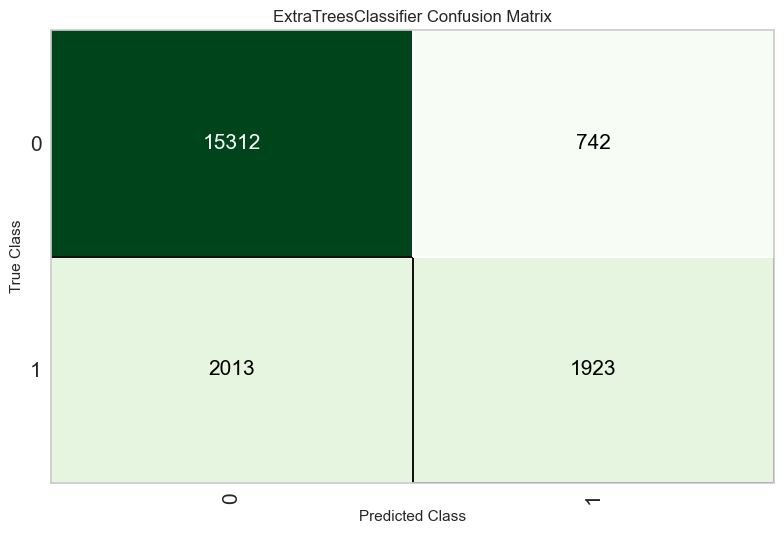


Confusion matrix - XGBClassifier


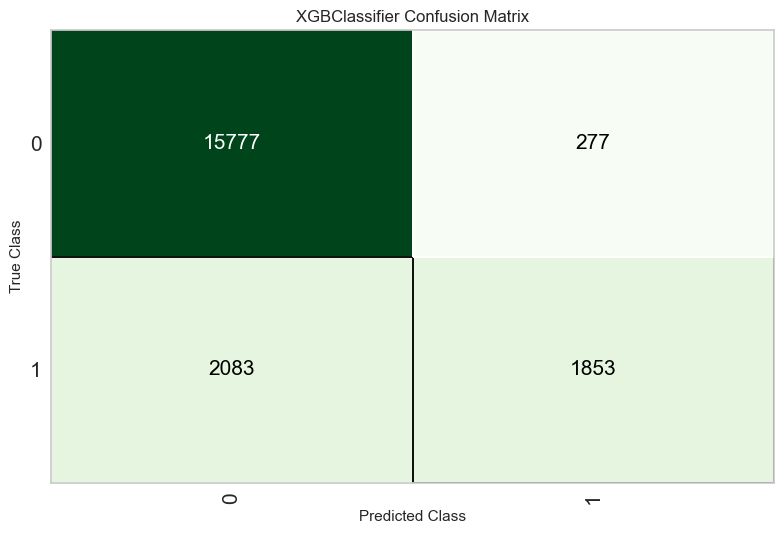

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [24]:
for m in tuned_model:
    print(f"\nConfusion matrix - {m.__class__.__name__}")
    exp.plot_model(m, 'confusion_matrix')

exp.evaluate_model(tuned_model[0])


## 10. Model selection and saving

Pick by holdout F1 (unseen data), not cross-validated ranking.

Refit on full dataset with `finalize_model()` and save with `save_model()`. Saves the whole pipeline including imputation, yeo-johnson, z-score normalization.

Web app loads the pipeline and applies transformations automatically. Rebuilding preprocessing separately is how models diverge between training and production.

In [25]:
best_name = holdout.sort_values('F1', ascending=False).index[0]
best_model = tuned_model[list(holdout.index).index(best_name)]
print(f"Best model by hold-out F1: {best_name}")

final_model = exp.finalize_model(best_model)  
import os
os.makedirs('../models', exist_ok=True)
path = f'../models/final_{best_name}'
exp.save_model(final_model, path)
print(f"Saved final model + pipeline to {path}")


Best model by hold-out F1: XGBClassifier


2026/08/21 12:56:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Transformation Pipeline and Model Successfully Saved
Saved final model + pipeline to ../models/final_XGBClassifier


## 11. Results, limitations, and next steps

### 11.1 Model comparison

10-fold cross-validated results, ranked by F1:

| Model | Accuracy | AUC | Recall | Precision | F1 | MCC |
|---|---|---|---|---|---|---|
| **Extra Trees** | 0.8605 | 0.7253 | 0.4741 | 0.7217 | **0.5721** | 0.5086 |
| Random Forest | 0.8459 | 0.7262 | 0.4853 | 0.6443 | 0.5535 | 0.4695 |
| XGBoost | 0.7919 | 0.7246 | 0.5283 | 0.4744 | 0.4998 | 0.3698 |
| AdaBoost | 0.7801 | 0.7249 | 0.5394 | 0.4512 | 0.4912 | 0.3548 |
| QDA | 0.7577 | 0.7127 | 0.5490 | 0.4140 | 0.4715 | 0.3242 |
| LDA | 0.7108 | 0.7154 | 0.5931 | 0.3590 | 0.4468 | 0.2827 |
| Naive Bayes | 0.7154 | 0.7059 | 0.5820 | 0.3616 | 0.4460 | 0.2821 |
| *Dummy* | 0.8031 | 0.5000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |

GBC excluded by config; LightGBM skipped.

**Key findings:**

AUC ranges 0.66–0.73 across all models—narrow, flat, driven by signal ceiling not model choice. Ranking is precision, not discrimination: extra trees wins on threshold placement, not on separating classes.

Tuning helped XGBoost (F1: 0.4998 → 0.6122) but not extra trees (defaults were best). Carrying three models forward (`n_select=3`) revealed this; keeping just the top untuned model would have missed the winner.

**Holdout performance** (19,990 rows, 3,936 need maintenance):

| Metric | Baseline | Extra Trees | **XGBoost** |
|---|---|---|---|
| Accuracy | 0.8031 | 0.8622 | 0.8833 |
| F1 | 0.0000 | 0.5826 | **0.6122** |
| Recall | 0.0000 | 0.4886 | 0.4677 |
| Precision | 0.0000 | 0.7216 | 0.8859 |

XGBoost selected on holdout F1. High precision (0.8859) trades for low recall: 2,095 of 3,936 machines needing maintenance went unflagged (53% miss rate). AUC identical across models (0.73), confirming the difference is threshold, not discrimination.

### 11.2 Limitations

1. **Weak signal in sensors.** AUC ceiling ~0.73 across all thirteen models, above chance but well below strong predictability. The flatness across naive bayes, knn, and extra trees says the limitation is in features, not model choice.
2. **Temporal features did not help.** Five raw sensors: best F1 0.6186 (adaboost), AUC 0.7295. Nineteen features: best F1 0.5721 (extra trees), AUC 0.7253. Slightly worse. Either degradation is not in these sensors, or SMOTE interpolates poorly in 19 dimensions.
3. **Random train/test split.** Engineered features are temporal meaning that consecutive readings overlap. Random split can put *t* in training and *t+1* in test, making holdout optimistic. Temporal or per-machine split would match deployment.
4. **Kfold not stratified.** Practical effect small at 128k rows, but stratifiedkfold guarantees constant class ratio and is the better default.
5. **SMOTE creates plausible, not observed, minority examples.** If the minority class is varied, interpolation blurs boundaries. 
6. **Single holdout split.** Repeat across seeds for confidence bounds instead of point estimates.

### 11.3 Conclusion

Tuned **XGBoost** selected. F1 0.6122 vs baseline 0.0000; accuracy 0.8833 vs 0.8031; MCC 0.5902 confirms real signal, not chance.

Caveats: discrimination is weak across all models (AUC 0.66 - 0.73), showing its most likely a case of feature ceiling and not model choice. Temportal features underperformed raw sensors, and operating point misses half the failures, while catching 89% of the flags. 

## 12. Registering the model in MLflow

Saving to disk versions a file; registering versions a decision. Registry gives incrementing version numbers tied to run parameters and metrics, so old versions can be restored if a new one regresses.

App requests a specific registered version instead of a file path that might get overwritten.

**Technical notes:**
- PyCaret leaves its run open; call `mlflow.end_run()` first, then `mlflow.start_run()`
- Use sklearn flavour, not pyfunc—the finalized object is a full pipeline, not a `PythonModel` subclass

In [27]:
print('final_model' in dir(), 'cfg' in dir(), 'exp' in dir())
import mlflow
print('active_run:', mlflow.active_run())


True True True
active_run: <ActiveRun: >


In [28]:
import mlflow

# Pycaret's own logging leaves an mlflow run open, so starting another one here
# fails with "Run ... is already active". End the open run first.
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="register_final") as run:
    mlflow.sklearn.log_model(final_model, artifact_path="model")
    mlflow.register_model(f"runs:/{run.info.run_id}/model",
                          cfg.model.experiment_name)
print("registered run_id:", run.info.run_id)
print("name:", cfg.model.experiment_name)


2026/08/21 13:34:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


registered run_id: 475e09d3e9724f7bacc39ec25bc9dbaa
name: smart_manufacturing_experiment


Successfully registered model 'smart_manufacturing_experiment'.
Created version '1' of model 'smart_manufacturing_experiment'.
